# Step 4 — TensorFlow ANN for inverse kinematics

Our first learned inverse-kinematics model approximates **[x, y] in cm → [theta1, theta2] in degrees**. This notebook covers data preparation, one baseline network, training diagnostics, and saved inference artifacts. Full forward-kinematics and Cartesian-error validation remain **Step 5**.

The model learns the existing Step 3.3 policy: prefer positive theta2, retain straight configurations, and use negative theta2 only when the preferred branch is invalid. We keep that policy unchanged, including its discontinuities. No architecture search or test-set model evaluation is performed.

Run from the repository root using a Python environment with `requirements-ann.txt`. Run cells in order to reproduce training. To make predictions without retraining, load the saved artifacts using the example in Section 4.8. The mathematical notebook and both source CSVs remain unchanged.

## 4.1 Load and inspect the ML dataset

Use `robot_ik_training.csv`: Step 3.3 selected one joint configuration per Cartesian target. The raw `robot_configurations.csv` contains conflicting angle labels and is not a training input here. Six-decimal Cartesian keys match the uniqueness convention validated in Step 3.3.

We fix seeds before creating the model and enable deterministic TensorFlow operations. Reproducibility depends on the recorded package versions and execution environment; different hardware/software can still produce different runs. CPU thread counts are bounded for this small model.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from pathlib import Path
from hashlib import sha256
import json
import platform
import importlib.metadata
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display

SEED = 42
tf.keras.utils.set_random_seed(SEED)  # Python, NumPy, and TensorFlow seeds.
tf.config.experimental.enable_op_determinism()
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

dataset_path = Path("data/robot_ik_training.csv")
dataset_sha256 = sha256(dataset_path.read_bytes()).hexdigest()
data = pd.read_csv(dataset_path)
feature_columns = ["x", "y"]
target_columns = ["theta1", "theta2"]
assert list(data.columns) == feature_columns + target_columns
assert data.shape == (39555, 4)
assert np.isfinite(data.to_numpy()).all()
assert not data.duplicated().any()
assert not data[feature_columns].round(6).duplicated().any()
assert data.theta1.between(-90, 180).all()
assert data.theta2.between(-120, 120).all()

print(f"Shape: {data.shape}; duplicate rows: {data.duplicated().sum()}")
print("Missing values:")
display(data.isna().sum().rename("missing"))
display(data.agg(["min", "max"]))
X = data[feature_columns]
y = data[target_columns]
versions = {package: importlib.metadata.version(package) for package in
            ["tensorflow", "keras", "numpy", "pandas", "scikit-learn", "matplotlib", "joblib", "protobuf"]}
print("Package versions:", versions)

Shape: (39555, 4); duplicate rows: 0
Missing values:


x         0
y         0
theta1    0
theta2    0
Name: missing, dtype: int64

,x,y,theta1,theta2
min,-20.0,-20.0,-90.0,-120.0
max,20.0,20.0,180.0,120.0


Package versions: {'tensorflow': '2.16.1', 'keras': '3.3.3', 'numpy': '1.24.3', 'pandas': '2.0.3', 'scikit-learn': '1.3.0', 'matplotlib': '3.7.2', 'joblib': '1.2.0', 'protobuf': '4.25.8'}


## 4.2 Reproducible training / validation / test split

First reserve 20% of row indices, then divide that holdout equally into validation and test sets using seed 42. Integer rounding gives **31,644 training / 3,955 validation / 3,956 test** samples. Saving the exact indices and dataset hash makes these sets reusable in Step 5.

The validation set monitors learning and selects the best epoch. The test set is reserved: only its sample count, input-coordinate coverage, and train-fitted preprocessing are inspected here. It is never passed to the model for prediction or evaluation in Step 4.

This random split measures interpolation among samples in the same workspace. Nearby positions can occur in different splits; results do not establish performance in unseen workspace regions or at branch-switch boundaries.

training      31644
validation     3955
test           3956
Name: Samples, dtype: int64

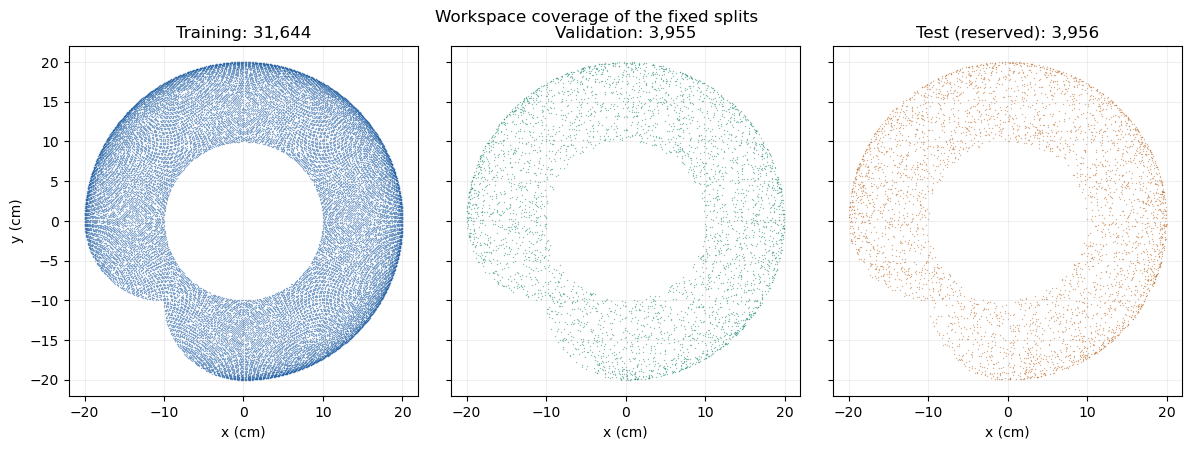

In [2]:
row_indices = np.arange(len(data))
train_indices, holdout_indices = train_test_split(row_indices, test_size=0.2, random_state=SEED)
val_indices, test_indices = train_test_split(holdout_indices, test_size=0.5, random_state=SEED)
assert not set(train_indices) & set(val_indices)
assert not set(train_indices) & set(test_indices)
assert not set(val_indices) & set(test_indices)
np.testing.assert_array_equal(np.sort(np.concatenate([train_indices, val_indices, test_indices])), row_indices)

X_train, y_train = X.iloc[train_indices], y.iloc[train_indices]
X_val, y_val = X.iloc[val_indices], y.iloc[val_indices]
X_test, y_test = X.iloc[test_indices], y.iloc[test_indices]
split_sizes = {"training": len(train_indices), "validation": len(val_indices), "test": len(test_indices)}
display(pd.Series(split_sizes, name="Samples"))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), sharex=True, sharey=True, layout="constrained")
for ax, (name, indices), colour in zip(axes,
    [("Training", train_indices), ("Validation", val_indices), ("Test (reserved)", test_indices)],
    ["#2563a6", "#16826c", "#b76520"]):
    ax.scatter(X.iloc[indices].x, X.iloc[indices].y, s=1, alpha=0.5, color=colour, linewidths=0)
    ax.set(title=f"{name}: {len(indices):,}", xlabel="x (cm)", xlim=(-22, 22), ylim=(-22, 22), aspect="equal")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("y (cm)")
fig.suptitle("Workspace coverage of the fixed splits")
plt.show()

## 4.3 Scale inputs and targets using training data only

`StandardScaler` learns each column's training mean and standard deviation, then applies $z=(v-\mu)/\sigma$. Separate scalers handle positions and angles. Fitting on validation or test rows would leak information into preprocessing, so only training rows call `.fit()`.

Input scaling makes the two coordinates comparable to the network. Output scaling balances the two joint targets in the loss. Scaled MSE and MAE are **dimensionless**, not cm or degrees. We inverse-transform validation predictions in Section 4.7 to report degree errors. The reserved test arrays are transformed with these same fixed scalers and then left unused.

In [3]:
input_scaler = StandardScaler().fit(X_train)
output_scaler = StandardScaler().fit(y_train)
X_train_scaled = input_scaler.transform(X_train).astype("float32")
X_val_scaled = input_scaler.transform(X_val).astype("float32")
X_test_scaled = input_scaler.transform(X_test).astype("float32")
y_train_scaled = output_scaler.transform(y_train).astype("float32")
y_val_scaled = output_scaler.transform(y_val).astype("float32")
y_test_scaled = output_scaler.transform(y_test).astype("float32")

assert input_scaler.n_samples_seen_ == len(train_indices)
assert output_scaler.n_samples_seen_ == len(train_indices)
np.testing.assert_allclose(input_scaler.mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
np.testing.assert_allclose(output_scaler.mean_, y_train.mean().to_numpy(), rtol=0, atol=1e-12)
np.testing.assert_allclose(X_train_scaled.mean(axis=0), 0, atol=1e-6)
np.testing.assert_allclose(y_train_scaled.mean(axis=0), 0, atol=1e-6)
print("Both scalers fitted on training rows only; all three splits transformed.")

Both scalers fitted on training rows only; all three splits transformed.


## 4.4 Build one simple regression baseline

- **Two inputs:** Cartesian x and y specify the target position.
- **Two hidden layers of 64 ReLU units:** introduce nonlinear relationships while keeping the model small. ReLU returns zero for a negative activation and the activation itself otherwise.
- **Two linear outputs:** predict continuous scaled joint angles, including negative values. Classification would choose discrete categories; our task estimates numerical angles.

Adam uses learning rate 0.001. MSE penalizes squared differences in scaled angles; MAE provides a second, more directly interpretable learning diagnostic. Linear outputs do not enforce joint limits, and no prediction clipping is applied. Checking predicted limits and physical reach belongs to Step 5.

### What the ANN is doing, in plain language

You give the network **x and y: where you want the robot hand to go**. The input scaler puts these values on comparable numerical scales, which helps training. The two hidden layers learn the nonlinear relationship between position and joint angles; **ReLU** lets them learn patterns beyond a straight-line relationship.

The two output neurons predict **scaled theta1 and theta2**. Their output is linear because angles are continuous numbers: this is **regression**, rather than choosing a class. The output scaler then converts the predictions back to degrees.

```text
Target [x, y] in cm
        ↓ Input scaler
Scaled [x, y]
        ↓ ANN: 2 → 64 ReLU → 64 ReLU → 2 Linear
Predicted [theta1, theta2] in scaled units
        ↓ Output inverse scaling
Predicted [theta1, theta2] in degrees
```

During training, the network adjusts its **weights** so predicted angles get closer to the known training angles. Separate validation samples help us check whether it learns a useful relationship beyond memorizing training samples. **Early stopping** ends training after validation stops improving and restores the best weights; this avoids unnecessary training when more epochs no longer help.


### The four ANN layers

Each box represents one layer; the hidden-layer boxes each contain **64 neurons**. Scaling happens around the ANN. Its two outputs become angles in degrees only after inverse scaling.


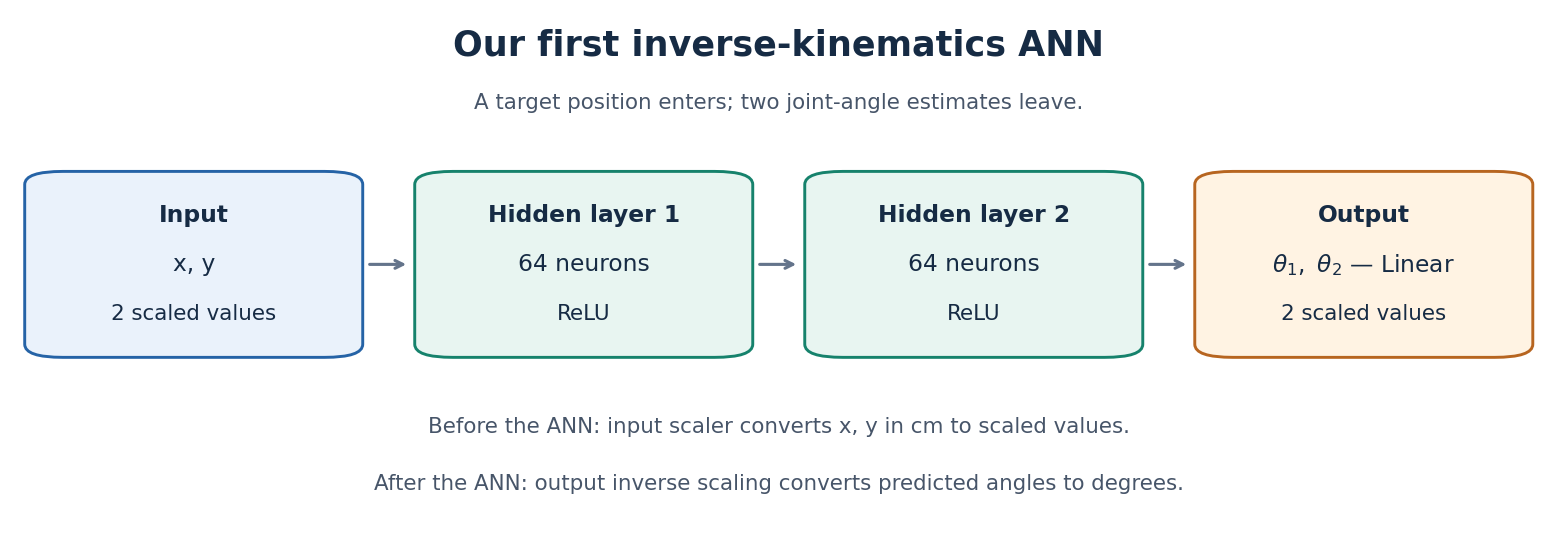

In [1]:
# Educational diagram only: this cell does not load, train, or evaluate the ANN.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

architecture_figure, architecture_axis = plt.subplots(figsize=(11.5, 4.1), dpi=140)
architecture_figure.patch.set_facecolor("white")
architecture_axis.set(xlim=(0, 1), ylim=(0, 1))
architecture_axis.set_axis_off()
architecture_figure.subplots_adjust(left=0.025, right=0.975, top=0.95, bottom=0.04)

architecture_axis.text(0.5, 0.94, "Our first inverse-kinematics ANN",
                       ha="center", va="center", fontsize=18, weight="bold", color="#162b44")
architecture_axis.text(0.5, 0.83, "A target position enters; two joint-angle estimates leave.",
                       ha="center", va="center", fontsize=11, color="#475569")

layer_boxes = [
    (0.015, "Input", "x, y", "2 scaled values", "#eaf2fb", "#2563a6"),
    (0.270, "Hidden layer 1", "64 neurons", "ReLU", "#e8f5f1", "#16826c"),
    (0.525, "Hidden layer 2", "64 neurons", "ReLU", "#e8f5f1", "#16826c"),
    (0.780, "Output", r"$\theta_1,\ \theta_2$ — Linear", "2 scaled values", "#fff3e3", "#b76520"),
]
box_width, box_bottom, box_height = 0.205, 0.35, 0.34
for x_position, heading, middle, detail, fill_colour, border_colour in layer_boxes:
    architecture_axis.add_patch(FancyBboxPatch(
        (x_position, box_bottom), box_width, box_height,
        boxstyle="round,pad=0.008,rounding_size=0.025",
        linewidth=1.5, edgecolor=border_colour, facecolor=fill_colour))
    for y_position, label, size, weight in [
        (0.615, heading, 12, "bold"), (0.520, middle, 12, "normal"),
        (0.425, detail, 11, "normal"),
    ]:
        architecture_axis.text(x_position + box_width / 2, y_position, label,
                               ha="center", va="center", fontsize=size,
                               weight=weight, color="#162b44")
for left, right in zip(layer_boxes[:-1], layer_boxes[1:]):
    architecture_axis.annotate("", xy=(right[0] - 0.011, 0.52),
                               xytext=(left[0] + box_width + 0.010, 0.52),
                               arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#64748b"})

architecture_axis.text(0.5, 0.21, "Before the ANN: input scaler converts x, y in cm to scaled values.",
                       ha="center", va="center", fontsize=11, color="#475569")
architecture_axis.text(0.5, 0.10, "After the ANN: output inverse scaling converts predicted angles to degrees.",
                       ha="center", va="center", fontsize=11, color="#475569")
plt.show()


In [4]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,), name="scaled_xy"),
    tf.keras.layers.Dense(64, activation="relu", name="hidden_1"),
    tf.keras.layers.Dense(64, activation="relu", name="hidden_2"),
    tf.keras.layers.Dense(2, activation="linear", name="scaled_angles"),
], name="ik_ann_baseline")
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="mse", metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
trainable_parameters = int(sum(np.prod(weight.shape) for weight in model.trainable_weights))
assert trainable_parameters == 4482
model.summary()

Model: "ik_ann_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaled_angles (Dense)           │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,482 (17.51 KB)

 Trainable params: 4,482 (17.51 KB)

 Non-trainable params: 0 (0.00 B)

## 4.5 Train with early stopping

An epoch is one pass over the training samples; batches of 128 update the weights incrementally. We allow at most 250 epochs. Early stopping monitors validation MSE, waits 20 epochs without improvement, and restores the weights from the best validation epoch. The test set has no role in this decision.

The architecture, learning rate, batch size, and stopping rule are fixed before this single experiment. Last-epoch history metrics may differ from the restored model's metrics, so we report them separately. Training prints periodic progress and saves the full numerical history later.

In [5]:
MAX_EPOCHS = 250
BATCH_SIZE = 128
PATIENCE = 20
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True, mode="min")

class TrainingProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:3d}: loss={logs['loss']:.6f}, val_loss={logs['val_loss']:.6f}", flush=True)

training_start = time.perf_counter()
history = model.fit(X_train_scaled, y_train_scaled,
                    validation_data=(X_val_scaled, y_val_scaled),
                    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, shuffle=True,
                    callbacks=[early_stopping, TrainingProgress(), tf.keras.callbacks.TerminateOnNaN()],
                    verbose=0)
training_seconds = time.perf_counter() - training_start
history_frame = pd.DataFrame(history.history)
history_frame.index = np.arange(1, len(history_frame) + 1)
history_frame.index.name = "epoch"
assert np.isfinite(history_frame.to_numpy()).all()
epochs_trained = len(history_frame)
best_epoch = int(history_frame.val_loss.idxmin())
best_validation_loss = float(history_frame.loc[best_epoch, "val_loss"])
print(f"Trained {epochs_trained} epochs in {training_seconds:.1f} seconds; best epoch: {best_epoch}.")
display(history_frame.loc[[best_epoch, epochs_trained]].rename_axis("epoch (best / last)"))

# These are validation-only metrics for the restored model, not the test set.
restored_validation = model.evaluate(X_val_scaled, y_val_scaled, verbose=0, return_dict=True)
np.testing.assert_allclose(restored_validation["loss"], best_validation_loss, rtol=1e-5, atol=1e-7)
print("Restored-model validation metrics (scaled):", restored_validation)

Epoch   1: loss=0.349026, val_loss=0.218194


Epoch  10: loss=0.033575, val_loss=0.031720


Epoch  20: loss=0.021186, val_loss=0.018553


Epoch  30: loss=0.016527, val_loss=0.013509


Epoch  40: loss=0.013769, val_loss=0.010010


...

Epoch 190: loss=0.008092, val_loss=0.004661


Epoch 200: loss=0.007829, val_loss=0.004572


Trained 207 epochs in 76.7 seconds; best epoch: 187.


,loss,mae,val_loss,val_mae
epoch (best / last),,,,
187,0.008162,0.032364,0.004404,0.028333
207,0.007683,0.031016,0.004526,0.026982


Restored-model validation metrics (scaled): {'loss': 0.00440394040197134, 'mae': 0.028333451598882675}


## 4.6 Inspect the learning curves

Both figures use dimensionless scaled errors. Falling training and validation curves indicate learning. A persistent rise in validation loss while training loss falls suggests overfitting; a plateau alone does not prove underfitting. The dashed line marks the best validation-loss epoch used for the saved weights.

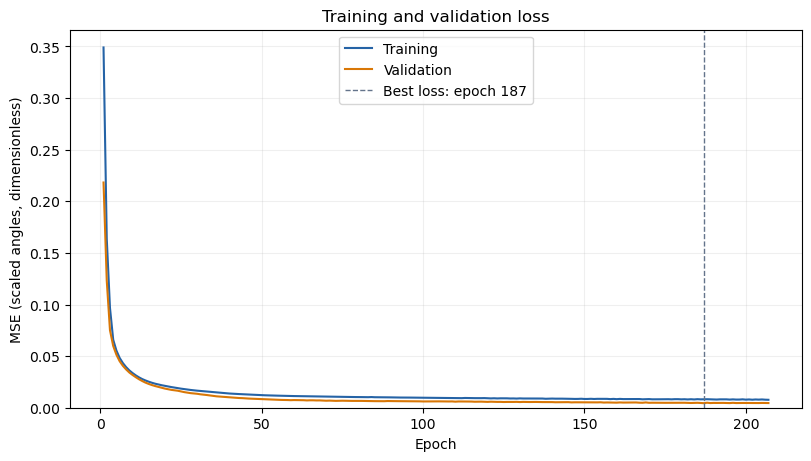

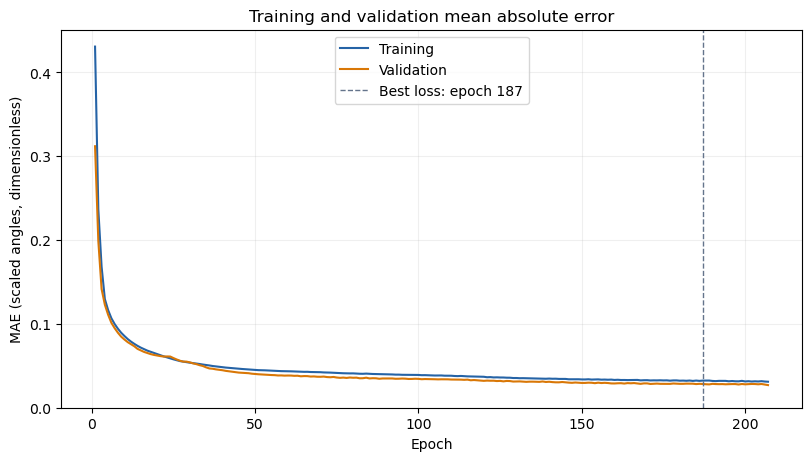

In [6]:
for metric, title, ylabel in [
    ("loss", "Training and validation loss", "MSE (scaled angles, dimensionless)"),
    ("mae", "Training and validation mean absolute error", "MAE (scaled angles, dimensionless)"),
]:
    fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
    ax.plot(history_frame.index, history_frame[metric], label="Training", color="#2563a6")
    ax.plot(history_frame.index, history_frame[f"val_{metric}"], label="Validation", color="#d97706")
    ax.axvline(best_epoch, linestyle="--", color="#64748b", linewidth=1, label=f"Best loss: epoch {best_epoch}")
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
    ax.legend()
    plt.show()

## 4.7 Validation angle errors in degrees

Use the restored best model and undo target scaling. Per-joint MAE is the mean absolute difference between predicted and selected target angles in degrees. The overall value averages both joint MAEs. These are direct joint-angle errors for our fixed labels, not a robotics success rate or Cartesian position error.

In [7]:
validation_predictions_scaled = model.predict(X_val_scaled, verbose=0)
validation_predictions_degrees = output_scaler.inverse_transform(validation_predictions_scaled)
angle_mae_degrees = np.abs(validation_predictions_degrees - y_val.to_numpy()).mean(axis=0)
overall_angle_mae = float(angle_mae_degrees.mean())
assert np.isfinite(validation_predictions_degrees).all()
display(pd.Series([*angle_mae_degrees, overall_angle_mae],
                   index=["theta1 MAE", "theta2 MAE", "Overall angle MAE"], name="Degrees"))
print("Validation sanity check only. No test evaluation or forward-kinematics evaluation performed.")

theta1 MAE           1.744729
theta2 MAE           2.176302
Overall angle MAE    1.960516
Name: Degrees, dtype: float64

Validation sanity check only. No test evaluation or forward-kinematics evaluation performed.


## 4.8 Save a reusable prediction pipeline

Save the restored best model in the native `.keras` format, both fitted scalers, exact split indices, numerical history, and a manifest recording dataset identity, units, versions, and results. Indices refer to zero-based CSV row positions after the header. Step 5 must check the dataset hash before reusing them.

Reload verification below uses a small **validation** batch and requires prediction agreement; it does not retrain or access test predictions. Scalers preserve the feature/target order and original units. These artifacts support inference; resuming the exact stopped optimization trajectory is not the purpose of this saved baseline.

In [8]:
model_directory = Path("models")
model_directory.mkdir(exist_ok=True)
model.save(model_directory / "ik_ann.keras")
joblib.dump(input_scaler, model_directory / "input_scaler.joblib")
joblib.dump(output_scaler, model_directory / "output_scaler.joblib")
np.savez_compressed(model_directory / "split_indices.npz",
                    train=train_indices, validation=val_indices, test=test_indices)
history_frame.to_csv(model_directory / "training_history.csv")
manifest = {
    "dataset": dataset_path.as_posix(), "dataset_sha256": dataset_sha256,
    "seed": SEED, "split_sizes": split_sizes, "split_index_base": 0,
    "features": feature_columns, "feature_units": "cm",
    "targets": target_columns, "target_units": "degrees",
    "policy": "Prefer positive theta2; retain straight; negative only as valid fallback",
    "scaling": "Separate StandardScaler for inputs and targets; fit on training rows only",
    "architecture": [2, 64, 64, 2], "hidden_activation": "relu", "output_activation": "linear",
    "trainable_parameters": trainable_parameters, "optimizer": "Adam", "learning_rate": 0.001,
    "loss": "scaled MSE", "metric": "scaled MAE", "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS, "patience": PATIENCE, "epochs_trained": epochs_trained,
    "best_epoch": best_epoch, "best_validation_loss": best_validation_loss,
    "last_epoch_training_loss": float(history_frame.loss.iloc[-1]),
    "last_epoch_training_mae": float(history_frame.mae.iloc[-1]),
    "last_epoch_validation_mae": float(history_frame.val_mae.iloc[-1]),
    "restored_validation_loss": float(restored_validation["loss"]),
    "restored_validation_mae_scaled": float(restored_validation["mae"]),
    "validation_theta1_mae_degrees": float(angle_mae_degrees[0]),
    "validation_theta2_mae_degrees": float(angle_mae_degrees[1]),
    "validation_overall_mae_degrees": overall_angle_mae,
    "training_seconds": training_seconds, "python": platform.python_version(), "versions": versions,
    "deterministic_ops": True, "oneDNN_enabled": False, "tensorflow_devices": [{"name": device.name, "type": device.device_type}
                           for device in tf.config.list_physical_devices()],
    "tensorflow_intra_op_threads": 2, "tensorflow_inter_op_threads": 2,
    "test_model_evaluation_performed": False, "cartesian_validation_performed": False,
}
(model_directory / "training_metadata.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")

loaded_model = tf.keras.models.load_model(model_directory / "ik_ann.keras", compile=False)
loaded_input_scaler = joblib.load(model_directory / "input_scaler.joblib")
loaded_output_scaler = joblib.load(model_directory / "output_scaler.joblib")
probe_xy = X_val.iloc[:8]
reloaded_degrees = loaded_output_scaler.inverse_transform(
    loaded_model.predict(loaded_input_scaler.transform(probe_xy).astype("float32"), verbose=0))
# Compare identical batch shapes to avoid float32 differences from batch-dependent kernels.
original_probe_degrees = output_scaler.inverse_transform(
    model.predict(input_scaler.transform(probe_xy).astype("float32"), verbose=0))
np.testing.assert_allclose(reloaded_degrees, original_probe_degrees, rtol=0, atol=1e-5)
assert sha256(dataset_path.read_bytes()).hexdigest() == dataset_sha256
print("Model and scalers reloaded successfully; validation predictions agree within 1e-5 degrees.")
print("Saved model:", model_directory / "ik_ann.keras")

Model and scalers reloaded successfully; validation predictions agree within 1e-5 degrees.
Saved model: models\ik_ann.keras


To predict later in a fresh session, without running the training cells:

```python
import json
import joblib
import pandas as pd
import tensorflow as tf

metadata = json.load(open("models/training_metadata.json", encoding="utf-8"))
model = tf.keras.models.load_model("models/ik_ann.keras", compile=False)
input_scaler = joblib.load("models/input_scaler.joblib")
output_scaler = joblib.load("models/output_scaler.joblib")
target_xy = pd.DataFrame([[10.0, 10.0]], columns=metadata["features"])
scaled_angles = model.predict(input_scaler.transform(target_xy).astype("float32"), verbose=0)
predicted_angles_degrees = output_scaler.inverse_transform(scaled_angles)
```

The code above is a loading example, not Step 5 evaluation. Predictions are unconstrained estimates; physical accuracy and joint-limit compliance have not yet been established.

References: [TensorFlow reproducibility](https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism), [EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping), and [Keras saving/loading](https://keras.io/guides/serialization_and_saving/).

## Step 4 results and review checkpoint

This one baseline run trained for **207 epochs** and early stopping restored **epoch 187**.

| Measurement | Value |
|---|---:|
| Last-epoch training MSE (scaled) | 0.00768264 |
| Last-epoch training MAE (scaled) | 0.03101613 |
| Best validation MSE (scaled) | 0.00440394 |
| Restored-model validation MAE (scaled) | 0.02833345 |
| Restored-model theta1 validation MAE | 1.7447 degrees |
| Restored-model theta2 validation MAE | 2.1763 degrees |
| Overall validation angle MAE | 1.9605 degrees |

The curves show **healthy learning followed by diminishing validation improvements**. There is no sustained rise in validation error indicating clear overfitting. Some late fluctuations are present, and early stopping retains the best validation-loss epoch. These curves alone do not establish whether the residual error is underfitting or concentrated near policy discontinuities; that needs further validation. Training metrics are collected while weights update, whereas validation uses the weights at epoch end, and the two splits contain different samples, so validation loss below training loss is not by itself a fault.

The checkpoint is selected by MSE, so its MAE need not be the lowest MAE seen at any epoch. The first IK policy and all data remain unchanged. The saved model and scalers reload successfully, with matching predictions for an identical validation batch. **No test-set model evaluation or Cartesian forward-kinematics validation has been performed. Review these Step 4 results before Step 5.**
